Text and Document Visualization

In [36]:
import pandas as pd
df=pd.read_csv(r"C:\Users\student\Desktop\Movies_Reviews_modified_version1.csv")
df.head()

,Unnamed: 0,Ratings,Reviews,movie_name,Resenhas,genres,Description,emotion
0,0,3.0,"It had some laughs, but overall the motivation...",Waiting to Exhale,"Riu algumas risadas, mas no geral a motivação ...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
1,1,4.0,"WAITING TO EXHALE Waiting, and waiting, and wa...",Waiting to Exhale,"ESPERANDO PARA EXALAR Esperando, e esperando, ...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
2,2,4.0,"Angela Basset was good as expected, but Whitne...",Waiting to Exhale,"Angela Basset foi boa como o esperado, mas Whi...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
3,3,5.0,"The movie is okay, mediocre might even be the ...",Waiting to Exhale,"O filme é bom, medíocre pode até ser a palavra...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
4,4,5.0,I got an opportunity to see Waiting To Exhale ...,Waiting to Exhale,Tive a oportunidade de ver Waiting To Exhale p...,"['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation


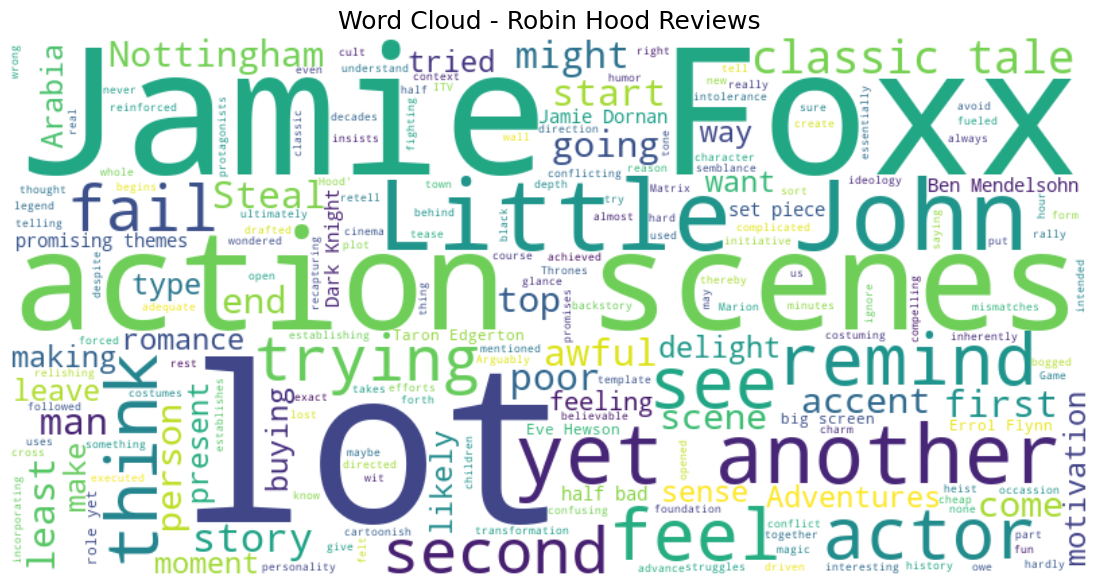

In [10]:
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import STOPWORDS
import re

movie_name ="Robin Hood"


reviews = df[df['movie_name'].str.lower() == movie_name.lower()]
text = " ".join(str(i) for i in reviews['Reviews'])

words = re.findall(r'\b[a-z]+\b', text.lower())  # Only alphabetic words

custom_stopwords = set(STOPWORDS)
custom_stopwords.update(["movie", "film","the" ])
custom_stopwords.update(movie_name.lower().split())

wordcloud = WordCloud(stopwords=custom_stopwords, background_color="white", width=800, height=400).generate(text)

# Display it
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title(f"Word Cloud - {movie_name} Reviews", fontsize=18)
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
C:\Users\student\AppData\Local\Temp\ipykernel_4856\923475244.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(words, rotation=45)
C:\Users\student\AppData\Local\Temp\ipykernel_4856\923475244.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(words, rotation=45)
C:\Users\student\AppData\Local\Temp\ipykernel_4856\923475244.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(words, rotation=45)
C:\Users\student\AppData\Local\Temp\ipykernel_4856\923475244.py:54: UserWarning: set_ticklabels() should only be used with a fi

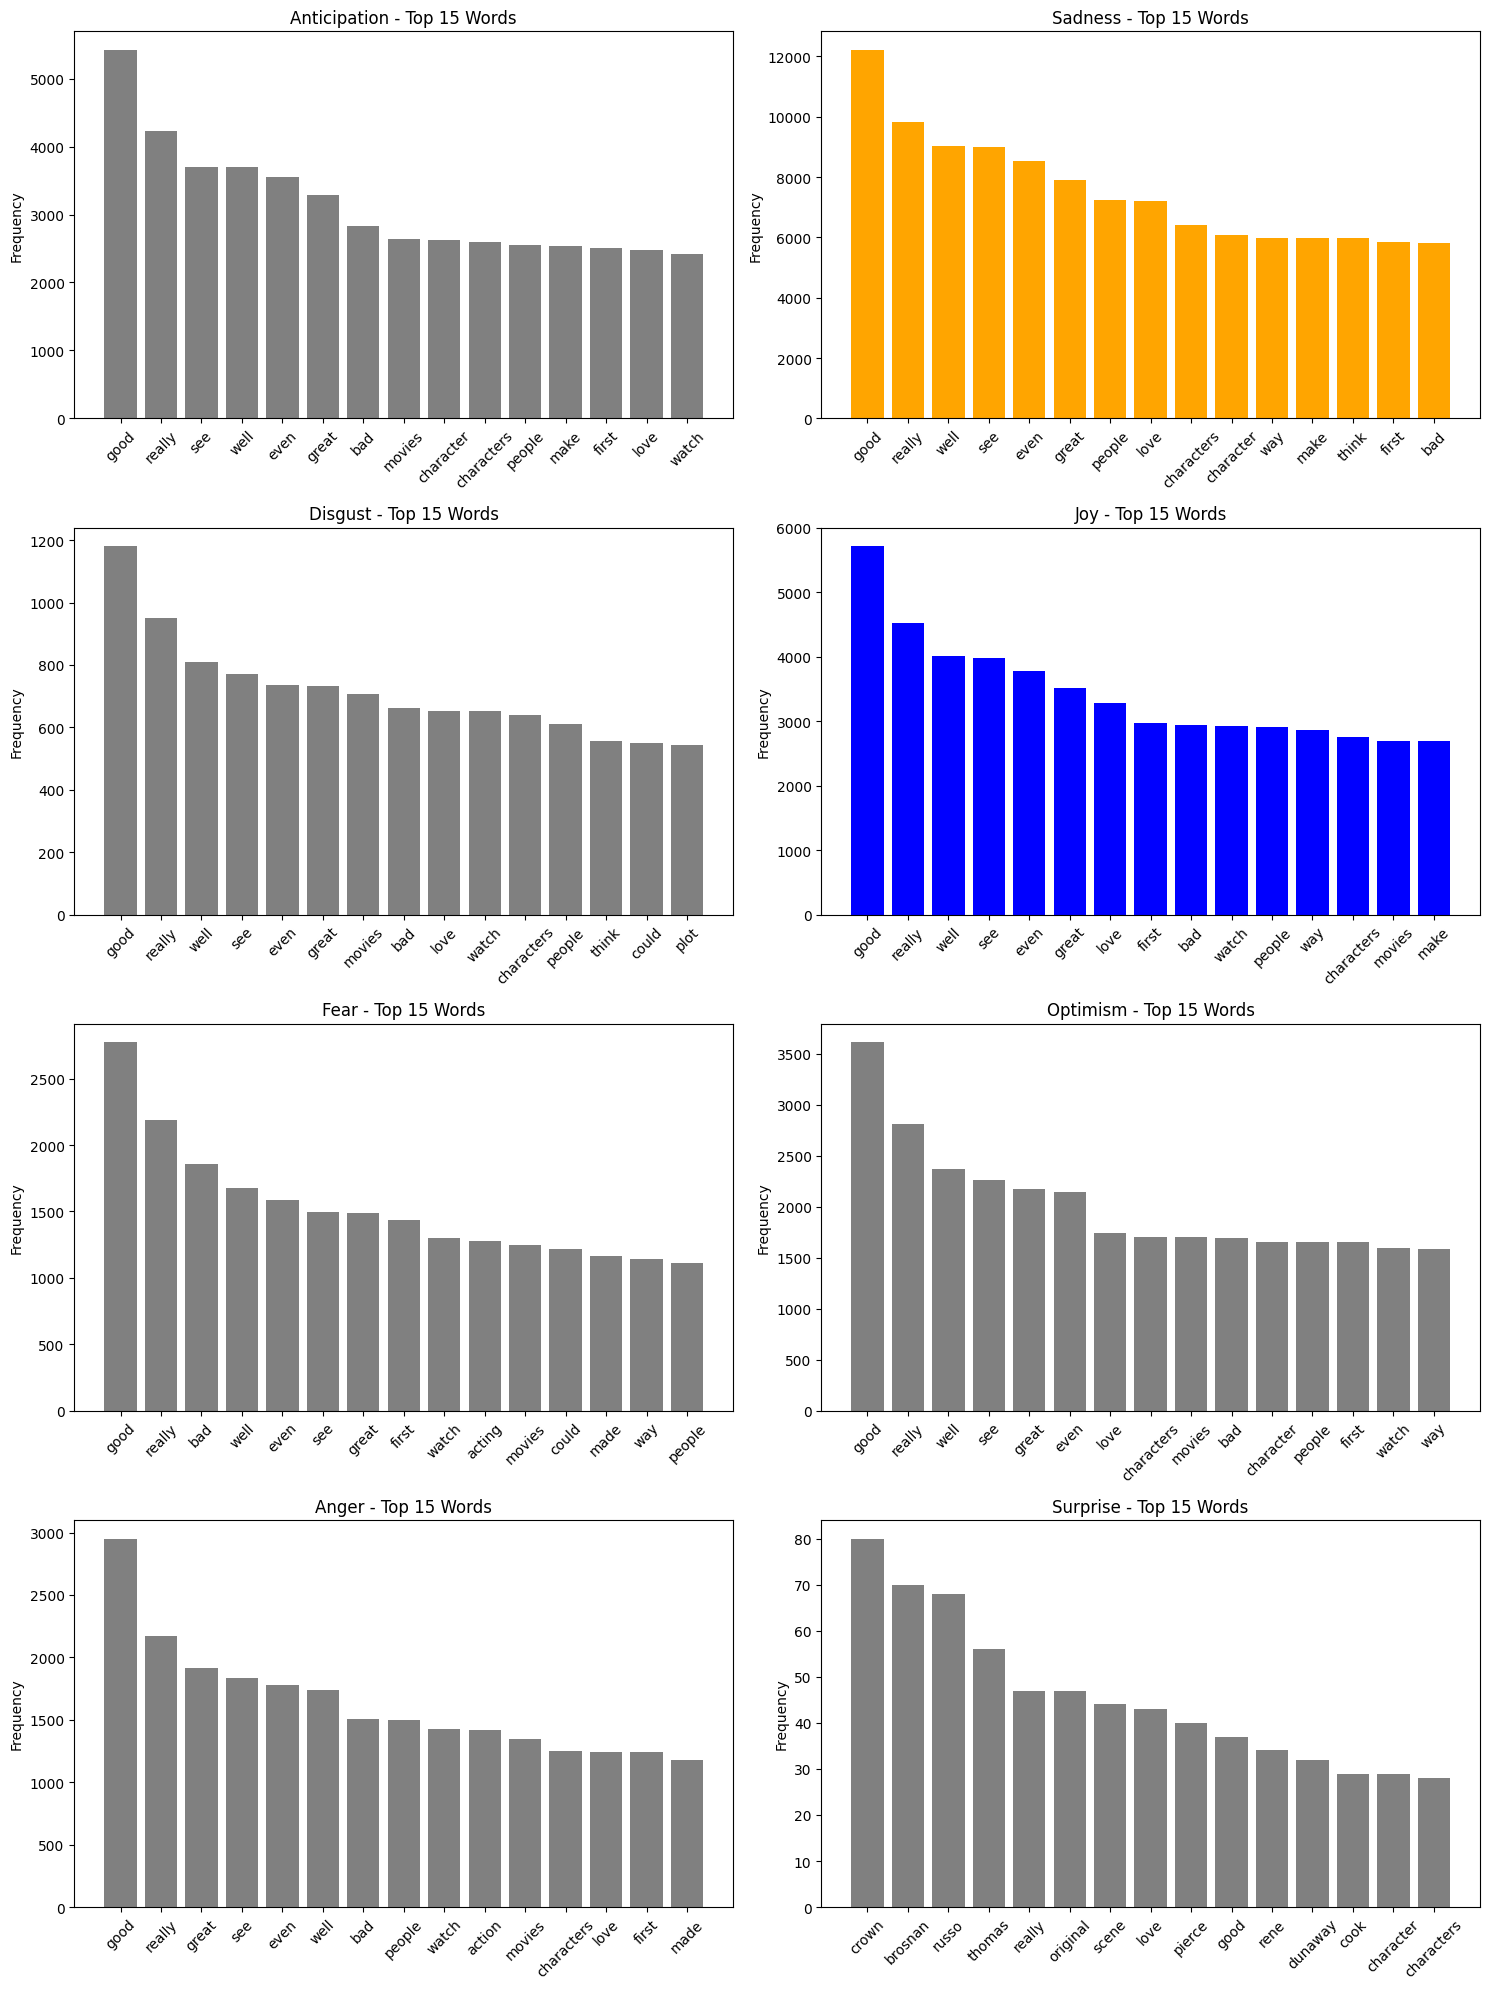

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
from nltk.corpus import stopwords
import nltk
import math

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
custom_stopwords = stop_words.union({'movie', 'film','the','one','movie','time','much','also','get','like','two','story'})  # Add your custom stopwords if needed

# Load your dataset
 # Replace with your file path

# Tokenize and remove stopwords
def tokenize(text):
    tokens = re.findall(r'\b[a-z]+\b', str(text).lower())
    return [word for word in tokens if word not in custom_stopwords]

# Emotion → color
emotion_colors = {
    'joy': 'blue',
    'sadness': 'orange'
}

# Get unique emotions
emotions = df['emotion'].dropna().unique()
num_emotions = len(emotions)

# Determine grid layout (e.g., 2 columns)
cols = 2
rows = math.ceil(num_emotions / cols)

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
axes = axes.flatten()  # Flatten in case of 2D grid

# Loop through emotions
for idx, emotion in enumerate(emotions):
    reviews = df[df['emotion'] == emotion]['Reviews']
    all_words = []
    for review in reviews:
        all_words.extend(tokenize(review))
        
    top_words = Counter(all_words).most_common(15)
    
    if top_words:
        words, counts = zip(*top_words)
        color = emotion_colors.get(emotion, 'gray')
        ax = axes[idx]
        ax.bar(words, counts, color=color)
        ax.set_title(f"{emotion.capitalize()} - Top 15 Words", fontsize=12)
        ax.set_xticklabels(words, rotation=45)
        ax.set_ylabel("Frequency")
    else:
        axes[idx].set_visible(False)

# Hide unused subplots if any
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


 Genre-Based Sentiment Heatmap

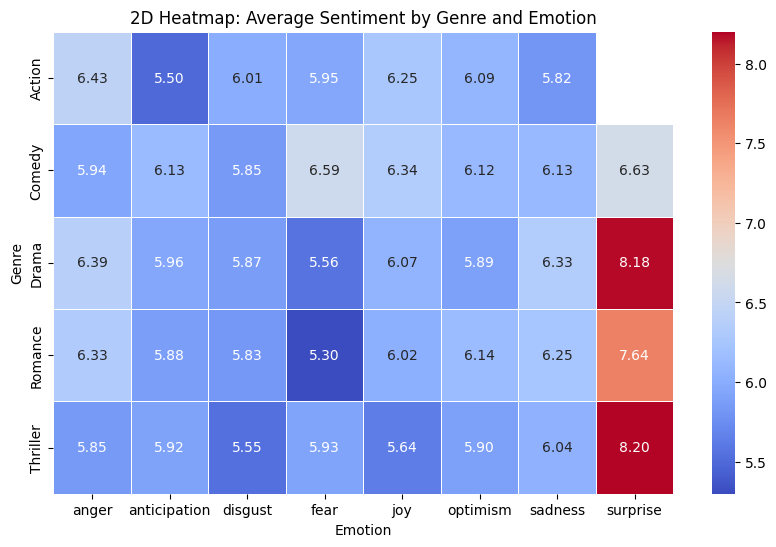

In [31]:

df['genres'] = df['genres'].apply(lambda x: eval(x) if isinstance(x, str) else x)
df_exploded = df.explode('genres')
target_genres = ['Action', 'Comedy', 'Drama', 'Thriller', 'Romance']
df_filtered = df_exploded[df_exploded['genres'].isin(target_genres)]
heatmap_data = df_filtered.pivot_table(index='genres', columns='emotion', values='Ratings', aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("2D Heatmap: Average Sentiment by Genre and Emotion")
plt.xlabel("Emotion")
plt.ylabel("Genre")
plt.show()


Compare Visualization Techniques:

Word cloud :
         Faster for getting a general idea
         
Bar chart:
        better for visualising, camparison

Bar Chart is better — when it comes to interpreting data accurately and quickly.

Text Analysis and Visualization Systems

In [38]:
df=pd.read_csv(r"C:\Users\student\Downloads\bbc_news_text_complexity_summarization.csv")
df.head()

,text,labels,no_sentences,Flesch Reading Ease Score,Dale-Chall Readability Score,text_rank_summary,lsa_summary
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,26,62.17,9.72,It hopes to increase subscribers by offering t...,Its profits were buoyed by one-off gains which...
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,17,65.56,9.09,The dollar has hit its highest level against t...,"""I think the chairman's taking a much more san..."
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,14,69.21,9.66,The owners of embattled Russian oil giant Yuko...,Yukos' owner Menatep Group says it will ask Ro...
3,High fuel prices hit BA's profits\n\nBritish A...,business,24,62.98,9.86,Looking ahead to its full year results to Marc...,"Rod Eddington, BA's chief executive, said the ..."
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,17,70.63,10.23,Reports in the Wall Street Journal and the Fin...,Shares in UK drinks and food firm Allied Domec...


Levels of Text Representations

C:\Users\student\AppData\Local\Temp\ipykernel_4856\1820237866.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score', y='term', data=top_terms, ax=axes[i], palette="viridis")
C:\Users\student\AppData\Local\Temp\ipykernel_4856\1820237866.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score', y='term', data=top_terms, ax=axes[i], palette="viridis")
C:\Users\student\AppData\Local\Temp\ipykernel_4856\1820237866.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score', y='term', data=top_terms, ax=axes[i], palette="viridis"

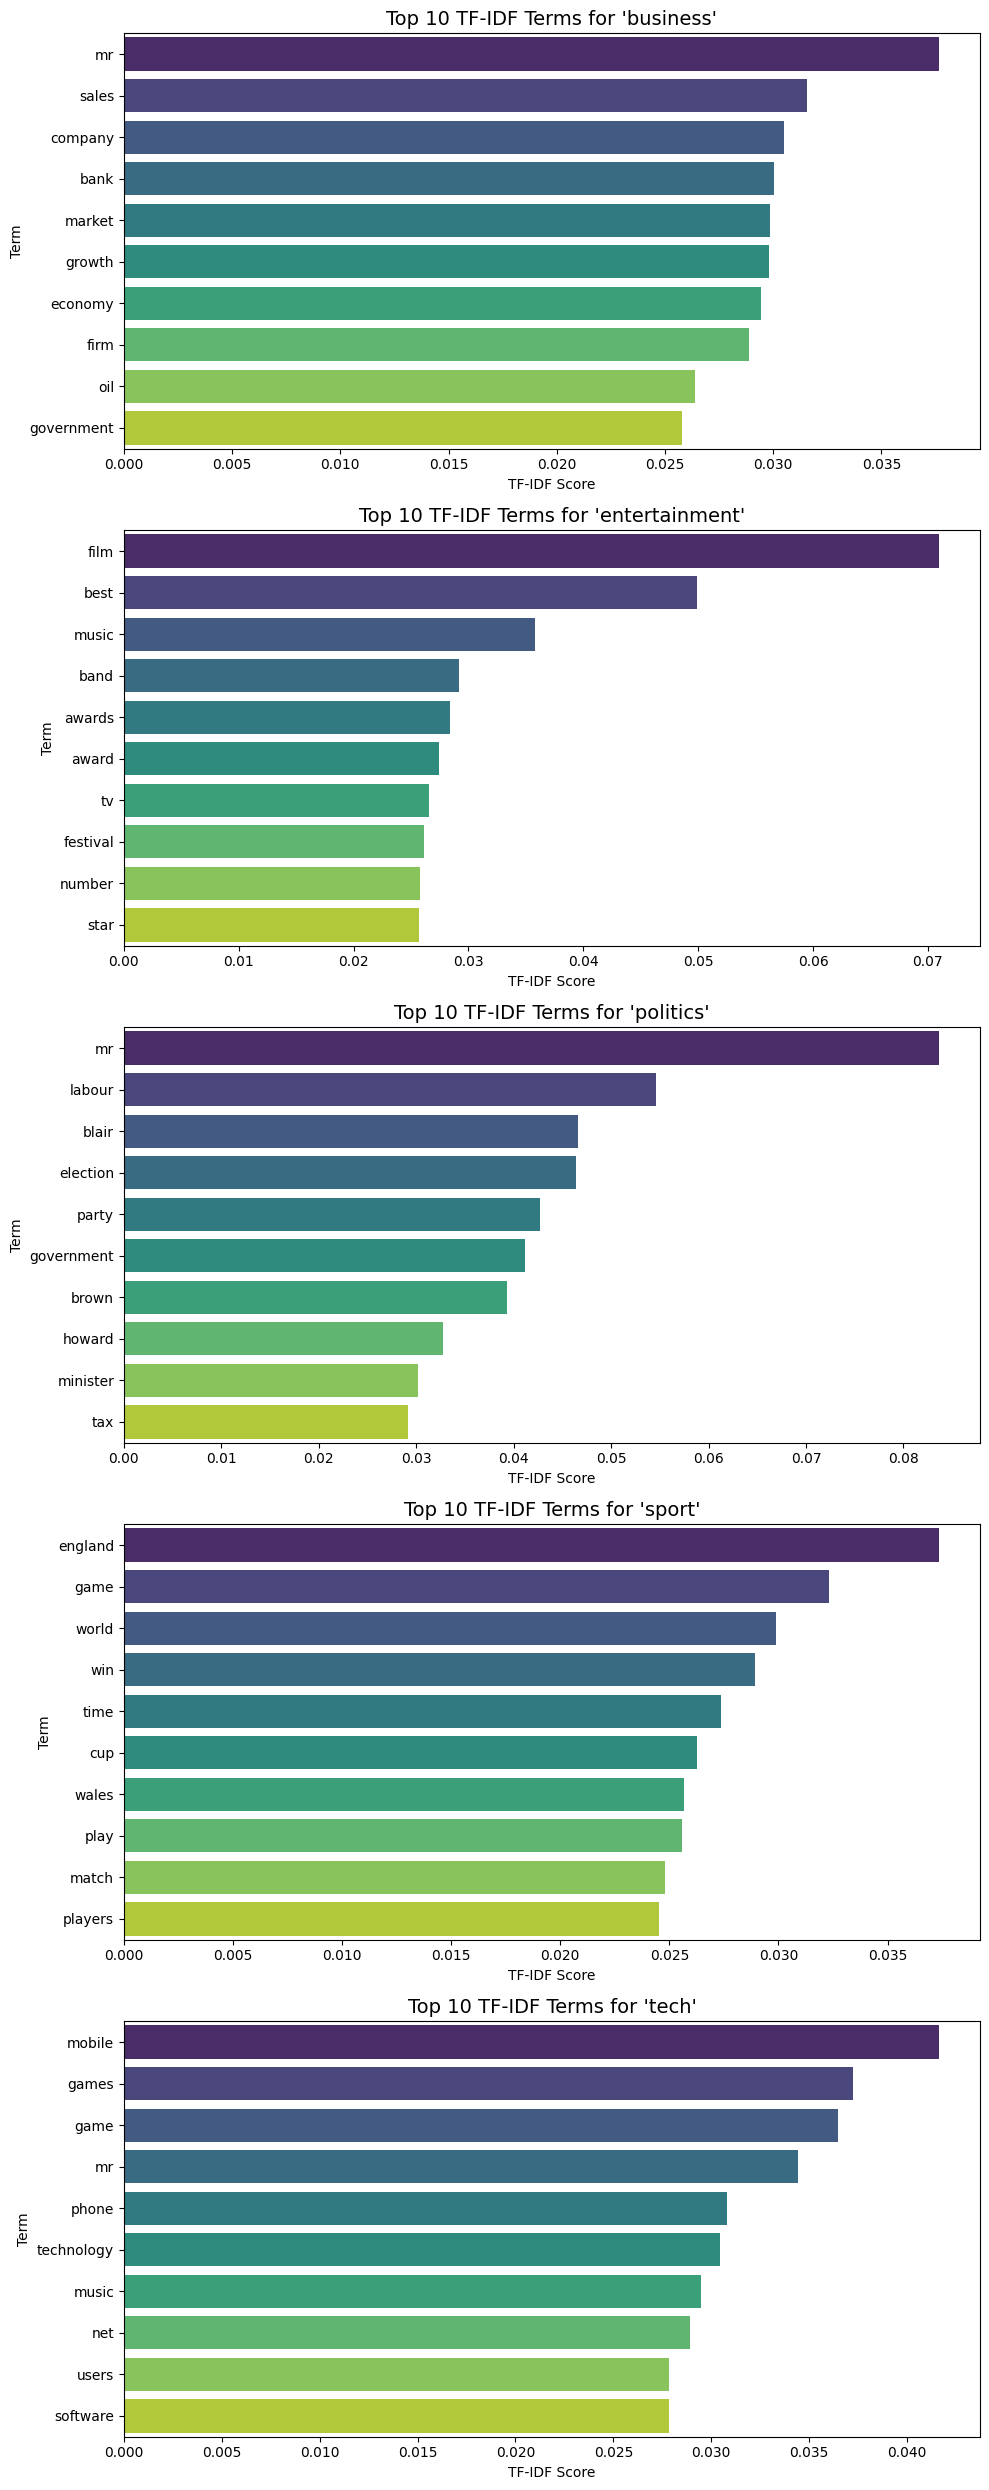

In [56]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

custom_stopwords = set([
    'mr','the', 'and', 'to', 'of', 'a', 'in', 'for', 'on', 'with', 'as', 'at','mr'
    'by', 'from', 'it', 'this', 'that', 'is', 'are', 'was', 'be', 'an',
    'or', 'not', 'have', 'has', 'had', 'will', 'would', 'can', 'could',
    'also', 'may', 'been', 'were', 'more', 'his', 'her', 'he', 'she',
    'we', 'they', 'you', 'i', 'them', 'their', 'our', 'us', 'who', 'which',
    'but', 'said', 'mr', 'mrs', 'one', 'two', 'new', 'year', 'make', 'like','said','mr'
])

categories = df['labels'].unique()
custom_stop_words = list(text.ENGLISH_STOP_WORDS.union(my_extra_stopwords))

vectorizer = TfidfVectorizer(stop_words=custom_stop_words, max_features=1000)

fig, axes = plt.subplots(len(categories), 1, figsize=(10, 5 * len(categories)))
if len(categories) == 1:
    axes = [axes]  

df['text'] = df['text'].astype(str).fillna('')

for i, category in enumerate(categories):
    texts = df[df['labels'] == category]['text']
    tfidf_matrix = vectorizer.fit_transform(texts)
    tfidf_scores = tfidf_matrix.mean(axis=0).A1  
    terms = vectorizer.get_feature_names_out()

    # Create DataFrame and select top 10
    term_scores_df = pd.DataFrame({'term': terms, 'score': tfidf_scores})
    top_terms = term_scores_df.sort_values(by='score', ascending=False).head(10)

    # Plotting
    sns.barplot(x='score', y='term', data=top_terms, ax=axes[i], palette="viridis")
    axes[i].set_title(f"Top 10 TF-IDF Terms for '{category}'", fontsize=14)
    axes[i].set_xlabel("TF-IDF Score")
    axes[i].set_ylabel("Term")

plt.tight_layout()
plt.show()


In [64]:

import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

docs = df['text'].dropna().tolist()[:500] 

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

cleaned_docs = [clean_text(doc) for doc in docs]
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(cleaned_docs)
terms = vectorizer.get_feature_names_out()
n_features = X.shape[1]
n_components = min(100, n_features - 1) 
svd = TruncatedSVD(n_components=n_components)
X_reduced = svd.fit_transform(X.T) 
word_embeddings = {term: X_reduced[i] for i, term in enumerate(terms)}
def get_similar_words(word, topn=5):
    if word not in word_embeddings:
        print(f"'{word}' not found in vocabulary.")
        return []
    word_vec = word_embeddings[word].reshape(1, -1)
    all_words = list(word_embeddings.keys())
    all_vecs = np.array([word_embeddings[w] for w in all_words])
    sims = cosine_similarity(word_vec, all_vecs)[0]
    top_indices = sims.argsort()[-topn-1:][::-1][1:]
    return [(all_words[i], round(sims[i], 3)) for i in top_indices]
target_word = "sales"
print(f"\nTop similar words to '{target_word}':")
similar = get_similar_words(target_word)
for word, score in similar:
    print(f"{word}: {score}")



Top similar words to 'sales':
endofyear: 0.805
accessory: 0.78
harris: 0.757
jumping: 0.756
stores: 0.751


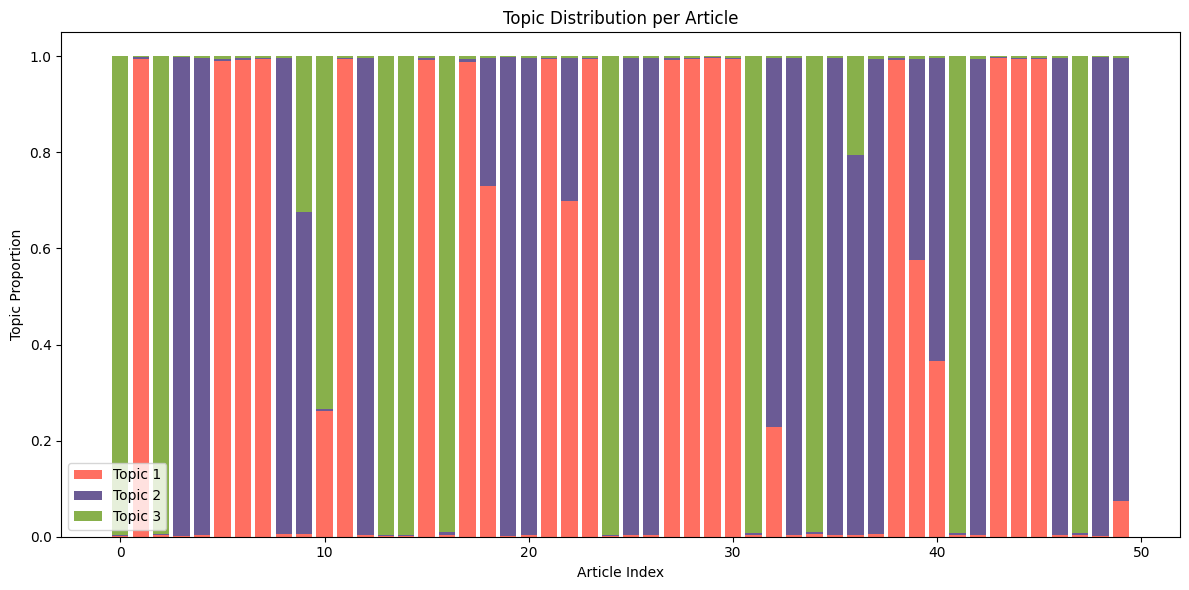

In [67]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
docs = df['text'].dropna().tolist()[:50] 
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

cleaned_docs = [clean_text(doc) for doc in docs]
vectorizer = CountVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(cleaned_docs)
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda_topic_distributions = lda.fit_transform(X)  
fig, ax = plt.subplots(figsize=(12, 6))
topic_probs = lda_topic_distributions.T 
colors = ['#FF6F61', '#6B5B95', '#88B04B']

for i in range(3):  # 3 topics
    ax.bar(range(len(cleaned_docs)), topic_probs[i], bottom=np.sum(topic_probs[:i], axis=0), color=colors[i], label=f"Topic {i+1}")

ax.set_title("Topic Distribution per Article")
ax.set_xlabel("Article Index")
ax.set_ylabel("Topic Proportion")
ax.legend()
plt.tight_layout()
plt.show()


C:\Users\student\AppData\Local\Temp\ipykernel_4856\2046719371.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


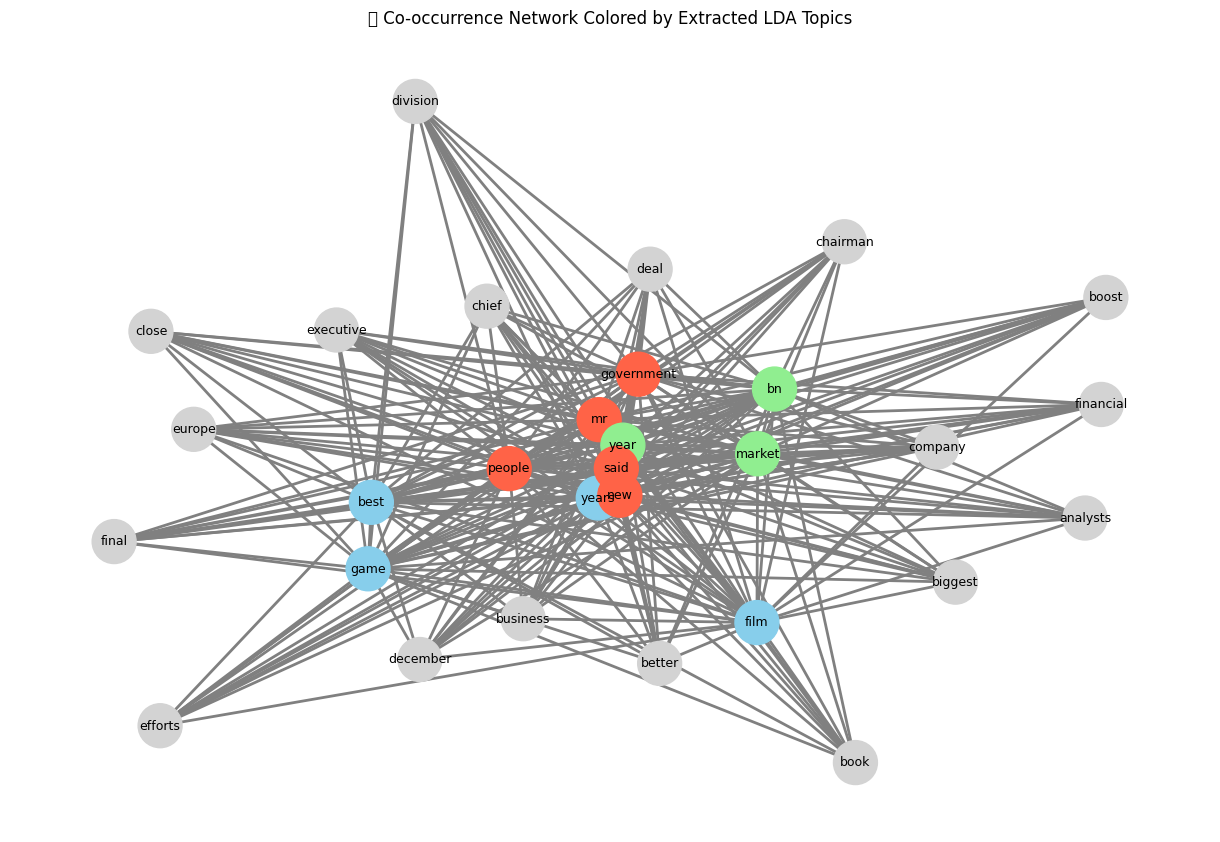

In [75]:
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from collections import defaultdict

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text
docs = df['text'].apply(clean_text)
vectorizer = CountVectorizer(stop_words='english', max_features=2000)
X = vectorizer.fit_transform(docs)
terms = vectorizer.get_feature_names_out()
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(X)
topic_keywords = {}
top_words = 5
for idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[-top_words:][::-1]
    topic_keywords[f'Topic {idx+1}'] = [terms[i] for i in top_indices]
co_occurrence = defaultdict(int)
for row in X.toarray():
    words_in_doc = [terms[i] for i, val in enumerate(row) if val > 0]
    for w1, w2 in combinations(words_in_doc, 2):
        pair = tuple(sorted((w1, w2)))
        co_occurrence[pair] += 1
topic_words_flat = [word for words in topic_keywords.values() for word in words]
edges = [(w1, w2, freq) for (w1, w2), freq in co_occurrence.items()
         if (w1 in topic_words_flat or w2 in topic_words_flat) and freq > 5]
G = nx.Graph()
for w1, w2, freq in edges:
    G.add_edge(w1, w2, weight=freq)

# Keep top 30 nodes by degree
top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:30]
G = G.subgraph([n for n, _ in top_nodes])
color_map = {
    'Topic 1': 'tomato',
    'Topic 2': 'skyblue',
    'Topic 3': 'lightgreen',
    'Other': 'lightgray'
}
node_colors = []
for node in G.nodes():
    assigned = False
    for topic, words in topic_keywords.items():
        if node in words:
            node_colors.append(color_map[topic])
            assigned = True
            break
    if not assigned:
        node_colors.append(color_map['Other'])

# Draw graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos,
        with_labels=True,
        node_color=node_colors,
        edge_color='gray',
        node_size=1000,
        font_size=9,
        width=2)
plt.title("🕸️ Co-occurrence Network Colored by Extracted LDA Topics")
plt.tight_layout()
plt.show()
